# Part 1: ML Pipelines

In [1]:
# Basic libraries
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train-test split and cross-validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

# Pipeline tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# IterativeImputer must be enabled before importing it
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Classifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42

In [2]:
csv_paths = []

for folder, subfolders, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_paths.append(os.path.join(folder, file))

print("CSV files found:")

for path in csv_paths:
    print(path)

CSV files found:
/kaggle/input/datasets/lara311/diabetes-dataset-using-many-medical-metrics/diabetes (1).csv


In [3]:
diabetes_files = [
    path for path in csv_paths
    if "diabetes" in os.path.basename(path).lower()
]

if len(diabetes_files) > 0:
    DATA_PATH = diabetes_files[0]
elif len(csv_paths) > 0:
    DATA_PATH = csv_paths[0]
else:
    raise FileNotFoundError("No CSV file was found in /kaggle/input")

print("Selected dataset:", DATA_PATH)

Selected dataset: /kaggle/input/datasets/lara311/diabetes-dataset-using-many-medical-metrics/diabetes (1).csv


Loading and Inspecting the Data

In [4]:
raw_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", raw_df.shape)
display(raw_df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


As we can see this a dataset for diabetes which contains multiple features that may be related to diabetes such as pregnancy, blood pressure, BMI,... etc.

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
display(raw_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


checking for missing values:

In [7]:
print("Ordinary missing values:")
display(raw_df.isna().sum().to_frame("Missing Count"))

Ordinary missing values:


,Missing Count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


As seen above there is not missing value and our dataset is clean and ready to work with

In [8]:
class_distribution = (
    raw_df["Outcome"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(raw_df) * 100
)

display(class_distribution)

,Count,Percentage
Outcome,,
0,500,65.104167
1,268,34.895833


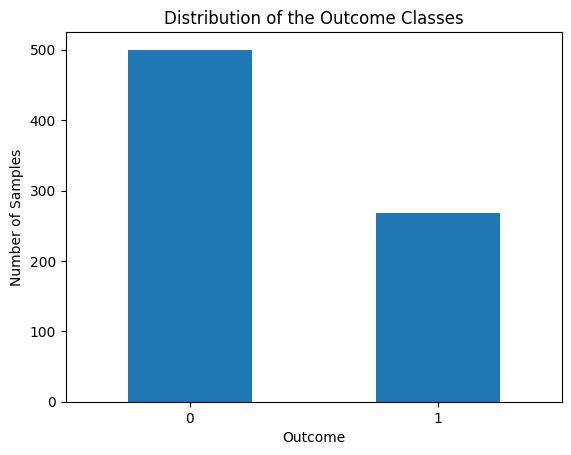

In [9]:
raw_df["Outcome"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribution of the Outcome Classes"
)

plt.xlabel("Outcome")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## PartA: Data Cleaning Pipeline using Pandas

Define expected columns

In [10]:
TARGET_COLUMN = "Outcome"

EXPECTED_COLUMNS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

ZERO_AS_MISSING_COLUMNS = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

Pregnancies is not included in ZERO_AS_MISSING_COLUMNS because zero pregnancies is a valid value.

create custom validation and cleaning functions

In [12]:
def validate_columns(data):
    """
    Check whether all required columns exist.
    """
    data = data.copy()

    missing_columns = [
        column for column in EXPECTED_COLUMNS
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Required columns are missing: {missing_columns}"
        )

    return data


def remove_duplicates(data):
    """
    Remove duplicated records.
    """
    data = data.copy()

    duplicate_count = data.duplicated().sum()
    print("Duplicated rows removed:", duplicate_count)

    data = data.drop_duplicates().reset_index(drop=True)

    return data


def replace_invalid_zeros(data):
    """
    Replace medically impossible zero values with NaN.
    """
    data = data.copy()

    data[ZERO_AS_MISSING_COLUMNS] = (
        data[ZERO_AS_MISSING_COLUMNS]
        .replace(0, np.nan)
    )

    return data

The original dataset contains only numerical predictors. However, the assignment specifically asks us to perform categorical encoding inside the pipeline.

We will create an engineered categorical feature called AgeGroup.

In [13]:
def add_age_group(data):
    """
    Convert Age into an additional categorical feature.
    """
    data = data.copy()

    data["AgeGroup"] = pd.cut(
        data["Age"],
        bins=[0, 29, 39, 49, 59, np.inf],
        labels=[
            "18-29",
            "30-39",
            "40-49",
            "50-59",
            "60+"
        ],
        include_lowest=True
    ).astype("object")

    return data

We keep the original Age feature and add AgeGroup. This allows the model to use both the exact numerical age and broader age categories.

In [14]:
def validate_values(data):
    """
    Check the target and prevent invalid negative values.
    """
    data = data.copy()

    valid_target_values = {0, 1}
    actual_target_values = set(data[TARGET_COLUMN].dropna().unique())

    if not actual_target_values.issubset(valid_target_values):
        raise ValueError(
            "Outcome must contain only 0 and 1."
        )

    numerical_columns = [
        column for column in EXPECTED_COLUMNS
        if column != TARGET_COLUMN
    ]

    contains_negative = (
        data[numerical_columns] < 0
    ).any().any()

    if contains_negative:
        raise ValueError(
            "Negative values were found in medical measurements."
        )

    return data

**Chaining all cleaning functions together**

In [15]:
clean_df = (
    pd.read_csv(DATA_PATH)
    .pipe(validate_columns)
    .pipe(remove_duplicates)
    .pipe(replace_invalid_zeros)
    .pipe(add_age_group)
    .pipe(validate_values)
)

print("Cleaned dataset shape:", clean_df.shape)
display(clean_df.head())

Duplicated rows removed: 0
Cleaned dataset shape: (768, 10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,50-59
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,30-39
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,30-39
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,18-29
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,30-39


In [16]:
missing_summary = (
    clean_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Count")
)

display(missing_summary)

,Missing Count
Insulin,374
SkinThickness,227
BloodPressure,35
BMI,11
Glucose,5
Pregnancies,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
AgeGroup,0


This is intentional. The Scikit-learn pipeline will impute them.

In [17]:
zero_summary = (
    raw_df[ZERO_AS_MISSING_COLUMNS]
    .eq(0)
    .sum()
    .to_frame("Invalid Zero Count")
)

display(zero_summary)

,Invalid Zero Count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


## Interpretation of the Data-Cleaning Results

The original dataset did not contain explicit missing values represented as `NaN`. However, several medical features contained values equal to zero. For some variables, zero is not a realistic physiological measurement and is therefore interpreted as an unrecorded or missing value.

The following columns were checked for medically invalid zero values:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

During the Pandas cleaning pipeline, these invalid zeros were converted to `NaN`. As a result, the cleaned dataset contains the following missing values:

| Feature | Missing Values | Approximate Percentage |
|---|---:|---:|
| Insulin | 374 | 48.7% |
| SkinThickness | 227 | 29.6% |
| BloodPressure | 35 | 4.6% |
| BMI | 11 | 1.4% |
| Glucose | 5 | 0.7% |

The large number of missing values in `Insulin` and `SkinThickness` indicates that these measurements were unavailable for many patients.

Zero values were not replaced in every column. For example, zero is a valid value for `Pregnancies`, because a patient may have had no pregnancies. Similarly, zero is a valid class label for `Outcome`, where:

- `Outcome = 0` represents no diabetes.
- `Outcome = 1` represents diabetes.

The `AgeGroup` feature was created from the `Age` column. Since all age values belonged to one of the defined age intervals, no missing values were produced in `AgeGroup`.

At the end of Part A, the missing values have only been identified and represented correctly as `NaN`; they have not yet been filled. They will be handled later using imputers inside the Scikit-learn preprocessing pipeline. This approach prevents the model from treating medically invalid zeros as genuine measurements and also helps avoid data leakage.

## Part B: Sicikit-learn Preprocessing Pipeline

In [18]:
X = clean_df.drop(columns=[TARGET_COLUMN])
y = clean_df[TARGET_COLUMN].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 9)
y shape: (768,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (614, 9)
Test set: (154, 9)


In [20]:
print("Full dataset class proportions:")
display(y.value_counts(normalize=True).sort_index())

print("Training class proportions:")
display(y_train.value_counts(normalize=True).sort_index())

print("Test class proportions:")
display(y_test.value_counts(normalize=True).sort_index())

Full dataset class proportions:


Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training class proportions:


Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test class proportions:


Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

**Identifying numerical and categorical columns**

In [21]:
categorical_features = ["AgeGroup"]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Categorical features:
['AgeGroup']


**Create a version-compatible one-hot encoder**

In [22]:
def create_one_hot_encoder():
    """
    Create OneHotEncoder for new and older sklearn versions.
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

In [23]:
def build_model_pipeline(numerical_imputer):
    """
    Create a full preprocessing and classification pipeline.
    """

    # Numerical branch
    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                clone(numerical_imputer)
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    # Categorical branch
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "one_hot_encoder",
                create_one_hot_encoder()
            )
        ]
    )

    # Apply different operations to different columns
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )

    # Classifier
    classifier = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    # Complete trainable pipeline
    complete_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    return complete_pipeline

## Part C: Compare Missing-Data Strategies

Defining four imputers

In [24]:
imputation_methods = {
    "Mean": SimpleImputer(
        strategy="mean"
    ),

    "Median": SimpleImputer(
        strategy="median"
    ),

    "KNN": KNNImputer(
        n_neighbors=5,
        weights="distance"
    ),

    "Iterative": IterativeImputer(
        max_iter=20,
        initial_strategy="median",
        random_state=RANDOM_STATE
    )
}

Mean imputation: replaces a missing value with the column mean.

Median imputation: replaces it with the median and is usually more resistant to outliers.

KNN imputation: finds similar records and estimates missing values from nearby observations.

Iterative imputation: predicts each incomplete feature using the other features.

**Compare imputers using stratified cross-validation**  
We only use the training set for this comparison. The test set must remain untouched until final model is selected.

In [25]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring_metrics = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy"
}

comparison_results = []

for imputer_name, imputer in imputation_methods.items():

    print(f"Evaluating {imputer_name} imputation...")

    model = build_model_pipeline(imputer)

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    comparison_results.append(
        {
            "Imputation": imputer_name,
            "ROC_AUC_Mean": scores["test_roc_auc"].mean(),
            "ROC_AUC_Std": scores["test_roc_auc"].std(),
            "F1_Mean": scores["test_f1"].mean(),
            "Balanced_Accuracy_Mean":
                scores["test_balanced_accuracy"].mean()
        }
    )

Evaluating Mean imputation...
Evaluating Median imputation...
Evaluating KNN imputation...
Evaluating Iterative imputation...


In [26]:
results_df = pd.DataFrame(comparison_results)

results_df = (
    results_df
    .sort_values(
        by="ROC_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df.round(4))

,Imputation,ROC_AUC_Mean,ROC_AUC_Std,F1_Mean,Balanced_Accuracy_Mean
0,Iterative,0.8525,0.0188,0.7004,0.7702
1,Mean,0.8524,0.0197,0.6935,0.7643
2,Median,0.8520,0.0210,0.6946,0.7655
3,KNN,0.8515,0.0211,0.6906,0.7615


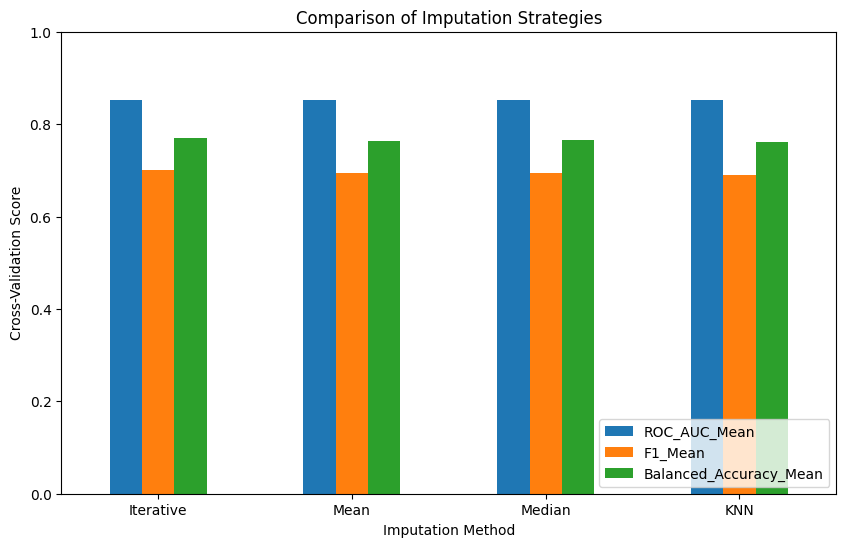

In [27]:
results_df.plot(
    x="Imputation",
    y=[
        "ROC_AUC_Mean",
        "F1_Mean",
        "Balanced_Accuracy_Mean"
    ],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Imputation Strategies")
plt.ylabel("Cross-Validation Score")
plt.xlabel("Imputation Method")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Part D: End-to-End Pipeline

We use mean ROC-AUC as the main selection criterion because the dataset is imbalanced

In [28]:
best_imputer_name = results_df.loc[0, "Imputation"]

print("Best imputation strategy:", best_imputer_name)

Best imputation strategy: Iterative


In [29]:
best_imputer = imputation_methods[best_imputer_name]

In [30]:
final_pipeline = build_model_pipeline(
    numerical_imputer=best_imputer
)

final_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(initial_strategy='median',
                                                                                    max_iter=20,
                                                                                    random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['AgeGroup'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [32]:
y_prediction = final_pipeline.predict(X_test)

y_probability = final_pipeline.predict_proba(X_test)[:, 1]

In [33]:
test_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy_score(y_test, y_prediction),
            balanced_accuracy_score(y_test, y_prediction),
            precision_score(y_test, y_prediction),
            recall_score(y_test, y_prediction),
            f1_score(y_test, y_prediction),
            roc_auc_score(y_test, y_probability)
        ]
    }
)

display(test_metrics.round(4))

,Metric,Value
0,Accuracy,0.7532
1,Balanced Accuracy,0.7504
2,Precision,0.6250
3,Recall,0.7407
4,F1-score,0.6780
5,ROC-AUC,0.8193


In [34]:
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.84      0.76      0.80       100
    Diabetes       0.62      0.74      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



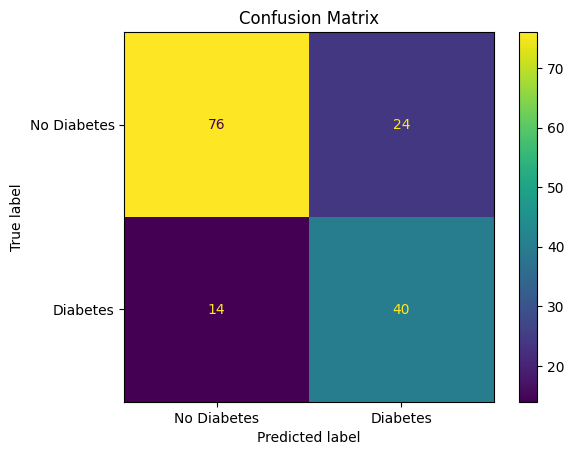

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ],
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

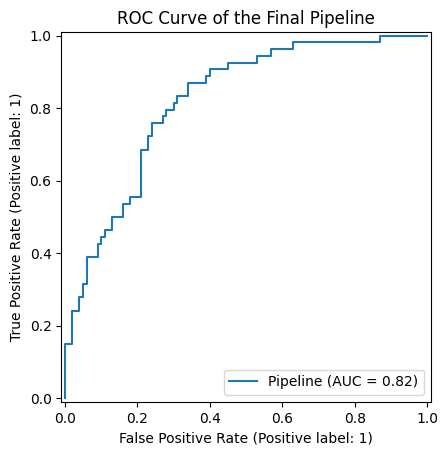

In [36]:
RocCurveDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test
)

plt.title("ROC Curve of the Final Pipeline")
plt.show()

In [37]:
transformed_feature_names = (
    final_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of transformed features:")
print(len(transformed_feature_names))

print("\nTransformed feature names:")
print(transformed_feature_names)

Number of transformed features:
13

Transformed feature names:
['numerical__Pregnancies' 'numerical__Glucose' 'numerical__BloodPressure'
 'numerical__SkinThickness' 'numerical__Insulin' 'numerical__BMI'
 'numerical__DiabetesPedigreeFunction' 'numerical__Age'
 'categorical__AgeGroup_18-29' 'categorical__AgeGroup_30-39'
 'categorical__AgeGroup_40-49' 'categorical__AgeGroup_50-59'
 'categorical__AgeGroup_60+']


In [38]:
MODEL_PATH = (
    "/kaggle/working/"
    "diabetes_complete_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print("Pipeline saved to:")
print(MODEL_PATH)

Pipeline saved to:
/kaggle/working/diabetes_complete_pipeline.joblib


In [39]:
loaded_pipeline = joblib.load(MODEL_PATH)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [40]:
original_predictions = final_pipeline.predict(
    X_test.iloc[:10]
)

loaded_predictions = loaded_pipeline.predict(
    X_test.iloc[:10]
)

print("Original predictions:")
print(original_predictions)

print("\nLoaded pipeline predictions:")
print(loaded_predictions)

print(
    "\nPredictions are identical:",
    np.array_equal(
        original_predictions,
        loaded_predictions
    )
)

Original predictions:
[1 0 0 0 0 0 1 1 0 1]

Loaded pipeline predictions:
[1 0 0 0 0 0 1 1 0 1]

Predictions are identical: True


## Interpretation of the Final Model Results

The final pipeline achieved an accuracy of 0.7532 on the test set, meaning
that approximately 75.3% of the 154 test samples were classified correctly.
The balanced accuracy was 0.7504, which was close to the ordinary accuracy.
This indicates that the model produced relatively balanced results across
the two target classes despite the unequal class sizes.

For the diabetes class, the model achieved a precision of 0.6250 and a recall
of 0.7407. Therefore, 62.5% of the patients predicted as diabetic were
actually diabetic, while approximately 74.1% of all truly diabetic patients
were successfully detected. The F1-score of 0.6780 represents the balance
between these two measures.

Based on the classification report, the model correctly identified 76 of the
100 non-diabetic patients and 40 of the 54 diabetic patients. It produced 24
false-positive predictions and 14 false-negative predictions. False negatives
are especially important in this medical classification problem because they
represent diabetic patients who were incorrectly classified as non-diabetic.

The ROC-AUC score was 0.8193, indicating that the model had good ability to
distinguish between diabetic and non-diabetic patients across different
classification thresholds. Overall, the pipeline provides a reasonable
baseline model, although its predictions should not be interpreted as a
clinical diagnosis.

In [41]:
sample_patients = X_test.iloc[:5].copy()

sample_results = sample_patients.copy()

sample_results["Actual_Outcome"] = (
    y_test.loc[sample_patients.index]
)

sample_results["Predicted_Outcome"] = (
    loaded_pipeline.predict(sample_patients)
)

sample_results["Diabetes_Probability"] = (
    loaded_pipeline.predict_proba(sample_patients)[:, 1]
)

display(sample_results)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,AgeGroup,Actual_Outcome,Predicted_Outcome,Diabetes_Probability
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40,40-49,0,1,0.835492
672,10,68.0,106.0,23.0,49.0,35.5,0.285,47,40-49,0,0,0.229016
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,18-29,0,0,0.391255
630,7,114.0,64.0,NaN,NaN,27.4,0.732,34,30-39,1,0,0.394451
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22,18-29,0,0,0.037810


In [42]:
sample_processed = (
    loaded_pipeline
    .named_steps["preprocessor"]
    .transform(sample_patients)
)

print(
    "Missing values after preprocessing:",
    np.isnan(sample_processed).sum()
)

Missing values after preprocessing: 0


In [43]:
feature_names = (
    loaded_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

sample_processed_df = pd.DataFrame(
    sample_processed,
    columns=feature_names,
    index=sample_patients.index
)

display(sample_processed_df)

,numerical__Pregnancies,numerical__Glucose,numerical__BloodPressure,numerical__SkinThickness,numerical__Insulin,numerical__BMI,numerical__DiabetesPedigreeFunction,numerical__Age,categorical__AgeGroup_18-29,categorical__AgeGroup_30-39,categorical__AgeGroup_40-49,categorical__AgeGroup_50-59,categorical__AgeGroup_60+
44,0.960541,1.243784,-0.661886,-0.257467,0.756188,-0.738658,-0.555791,0.561034,0.0,0.0,1.0,0.0,0.0
672,1.866489,-1.788623,2.754694,-0.626623,-1.089695,0.448855,-0.583061,1.153060,0.0,0.0,1.0,0.0,0.0
700,-0.549372,0.010827,0.314279,-0.207835,0.600824,0.507498,0.016882,-0.623019,1.0,0.0,0.0,0.0,0.0
630,0.960541,-0.255758,-0.661886,-0.448677,-0.268422,-0.738658,0.771356,0.053583,0.0,1.0,0.0,0.0,0.0
81,-0.549372,-1.588684,-0.491099,-0.487925,-1.133622,-0.345039,-1.137554,-0.961320,1.0,0.0,0.0,0.0,0.0


### Interpretation of Sample Predictions

The table shows five original test records together with their actual classes,
predicted classes, and estimated diabetes probabilities. Some original feature
values are still displayed as `NaN` because the table was created from the
unprocessed test DataFrame. However, these missing values were imputed
internally by the saved preprocessing pipeline before classification.

The classifier uses a default probability threshold of 0.5. Probabilities
greater than or equal to 0.5 are assigned to class 1, while lower probabilities
are assigned to class 0. The sample contains both correct and incorrect
predictions, including a false positive and a false negative. Such errors are
expected, and the false-negative cases are particularly important when
evaluating a medical screening model.

# Part 2: Handling Imbalanced Data

### Dataset Preparation

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

In [45]:
excel_paths = []

for folder, subfolders, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".xlsx", ".xls")):
            excel_paths.append(os.path.join(folder, file))

print("Excel files found:")

for path in excel_paths:
    print(path)

Excel files found:
/kaggle/input/datasets/baguspurnama/glass-imbalanced/glass (Imbalanced).xlsx


In [46]:
glass_files = [
    path for path in excel_paths
    if "glass" in os.path.basename(path).lower()
]

if len(glass_files) == 0:
    raise FileNotFoundError(
        "No Excel file containing 'glass' was found."
    )

DATA_PATH = glass_files[0]

print("Selected dataset:")
print(DATA_PATH)

Selected dataset:
/kaggle/input/datasets/baguspurnama/glass-imbalanced/glass (Imbalanced).xlsx


In [47]:
df_raw = pd.read_excel(
    DATA_PATH,
    dtype=object
)

print("Raw dataset shape:", df_raw.shape)

display(df_raw.head())

Raw dataset shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Class
0,151588824,1287795,343036,140066,73282,0.68931,804468,0.0,0.1224,negative
1,15176423,129777,353812,121127,73002,0.65205,852888,0.0,0.0,negative
2,152212996,1420795,382099,0.46976,71.77,0.11178,95726,0.0,0.0,negative
3,152222108,1321045,37716,0.79076,719884,0.13041,102452,0.0,0.0,negative
4,151755118,13.39,365935,11888,727892,0.57132,827064,0.0,0.0561,negative


The values above need to be repaired before modeling

In [48]:
df_raw = pd.read_excel(
    DATA_PATH,
    dtype=object
)

print("Raw dataset shape:", df_raw.shape)

display(df_raw.head())

Raw dataset shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Class
0,151588824,1287795,343036,140066,73282,0.68931,804468,0.0,0.1224,negative
1,15176423,129777,353812,121127,73002,0.65205,852888,0.0,0.0,negative
2,152212996,1420795,382099,0.46976,71.77,0.11178,95726,0.0,0.0,negative
3,152222108,1321045,37716,0.79076,719884,0.13041,102452,0.0,0.0,negative
4,151755118,13.39,365935,11888,727892,0.57132,827064,0.0,0.0561,negative


In [49]:
print("Original column names:")

for column in df_raw.columns:
    print(repr(column))

Original column names:
'RI'
' Na'
' Mg'
' Al'
' Si'
' K'
' Ca'
' Ba'
' Fe'
'Class'


**Defining valid feature ranges**  
These ranges allow us to determine how far the misplaced decimal point needs to be shifted.

In [50]:
FEATURE_RANGES = {
    "RI": (1.0, 2.0),
    "Na": (5.0, 25.0),
    "Mg": (0.0, 6.0),
    "Al": (0.0, 5.0),
    "Si": (60.0, 85.0),
    "K": (0.0, 8.0),
    "Ca": (4.0, 25.0),
    "Ba": (0.0, 5.0),
    "Fe": (0.0, 1.0)
}

creating a function to restore decimal points

In [52]:
def repair_decimal_value(value, minimum, maximum):
    """
    Convert a mixed Excel value to float and move the decimal
    point left until the value enters its valid feature range.
    """

    if pd.isna(value):
        return np.nan

    number = float(str(value).strip())

    while number > maximum:
        number = number / 10.0

    if not minimum <= number <= maximum:
        raise ValueError(
            f"Value {value} could not be repaired "
            f"to range [{minimum}, {maximum}]."
        )

    return number

clean the complete datset

In [54]:
df = df_raw.copy()

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Repair all numerical features
for column, limits in FEATURE_RANGES.items():

    minimum, maximum = limits

    df[column] = df[column].apply(
        lambda value: repair_decimal_value(
            value,
            minimum,
            maximum
        )
    )

# Remove spaces from target labels
df["Class"] = (
    df["Class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert target labels to 0 and 1
df["Class"] = df["Class"].map(
    {
        "negative": 0,
        "positive": 1
    }
)

# Validate target conversion
if df["Class"].isna().any():
    raise ValueError(
        "Some class labels could not be converted."
    )

df["Class"] = df["Class"].astype(int)

In [55]:
duplicate_count = df.duplicated().sum()

print("Duplicate records found:", duplicate_count)

df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Shape after duplicate removal:", df.shape)

Duplicate records found: 1
Shape after duplicate removal: (213, 10)


In [56]:
display(df.head())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Class
0,1.515888,12.87795,3.43036,1.40066,73.2820,0.68931,8.04468,0.0,0.1224,0
1,1.517642,12.97770,3.53812,1.21127,73.0020,0.65205,8.52888,0.0,0.0000,0
2,1.522130,14.20795,3.82099,0.46976,71.7700,0.11178,9.57260,0.0,0.0000,0
3,1.522221,13.21045,3.77160,0.79076,71.9884,0.13041,10.24520,0.0,0.0000,0
4,1.517551,13.39000,3.65935,1.18880,72.7892,0.57132,8.27064,0.0,0.0561,0


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      213 non-null    float64
 1   Na      213 non-null    float64
 2   Mg      213 non-null    float64
 3   Al      213 non-null    float64
 4   Si      213 non-null    float64
 5   K       213 non-null    float64
 6   Ca      213 non-null    float64
 7   Ba      213 non-null    float64
 8   Fe      213 non-null    float64
 9   Class   213 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [58]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
RI,213.0,1.518348,0.003033,1.51115,1.516526,1.517688,1.519146,1.53393
Na,213.0,13.409679,0.819902,10.73000,12.897900,13.296900,13.808950,17.38000
Mg,213.0,2.679181,1.443621,0.00000,2.087850,3.479750,3.600980,4.49000
Al,213.0,1.449473,0.496015,0.29000,1.188800,1.358930,1.628570,3.50000
Si,213.0,72.659807,0.778103,69.81000,72.279600,72.789200,73.097200,75.41000
K,213.0,0.499045,0.653185,0.00000,0.130410,0.558900,0.608580,6.21000
Ca,213.0,8.957664,1.429361,5.43000,8.238360,8.604200,9.152960,16.19000
Ba,213.0,0.178396,0.498948,0.00000,0.000000,0.000000,0.000000,3.15000
Fe,213.0,0.042811,0.092645,0.00000,0.000000,0.000000,0.056100,0.51000
Class,213.0,0.136150,0.343756,0.00000,0.000000,0.000000,0.000000,1.00000


In [59]:
missing_summary = (
    df
    .isna()
    .sum()
    .to_frame("Missing Count")
)

display(missing_summary)

,Missing Count
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Class,0


### Examining the class imbalance

In [60]:
class_summary = (
    df["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .to_frame("Count")
)

class_summary["Label"] = [
    "Negative",
    "Positive"
]

class_summary["Percentage"] = (
    class_summary["Count"]
    / len(df)
    * 100
)

display(class_summary)

,Count,Label,Percentage
Class,,,
0,184,Negative,86.384977
1,29,Positive,13.615023


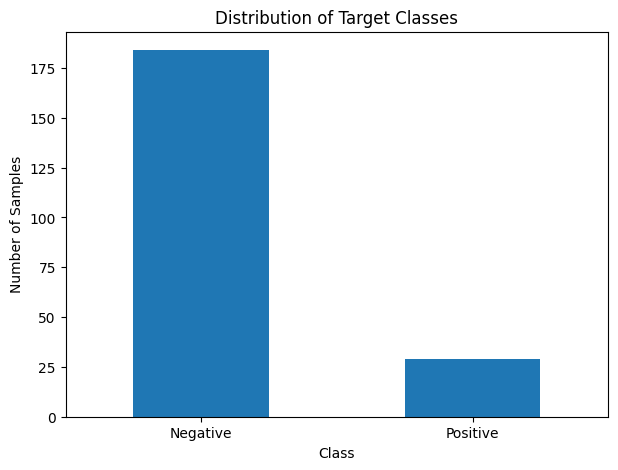

In [61]:
class_counts = (
    df["Class"]
    .value_counts()
    .sort_index()
)

class_counts.index = [
    "Negative",
    "Positive"
]

class_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

## Dataset Inspection and Cleaning

The cleaned glass dataset contains 213 unique records, nine numerical input
features, and one binary target variable named `Class`. The original Excel
file contained 214 records, but one exact duplicated record was identified
and removed.

An important formatting problem was found in the Excel file. During the
original Excel import, the dot character was interpreted as a thousands
separator rather than a decimal separator. As a result, values such as
`1.51588824` were stored as `151588824`, while some other values remained
text strings containing decimal points. These inconsistent values were
converted to numerical form, and their decimal positions were restored using
the valid range of each glass feature.

Spaces were also removed from column names and class labels. The target
labels were encoded as follows:

- `negative` was encoded as class 0.
- `positive` was encoded as class 1.

After cleaning and duplicate removal, the dataset contains 184 negative
samples and 29 positive samples. Therefore, approximately 86.4% of the
records belong to the negative class, while only approximately 13.6% belong
to the positive class. The majority-to-minority ratio is approximately
6.3 to 1, confirming that this is an imbalanced binary-classification
problem.

No missing values remain in the cleaned dataset. All input features are
numerical, so categorical encoding is not required. Feature scaling will
still be necessary, particularly before applying distance-based methods
such as SMOTE.

In [62]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (213, 9)
y shape: (213,)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (170, 9)
Test shape: (43, 9)


In [64]:
print("Training class counts:")
display(
    y_train
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

print("Test class counts:")
display(
    y_test
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

Training class counts:


,Count
Class,
0,147
1,23


Test class counts:


,Count
Class,
0,37
1,6


### Training baseline model on imbalanced dataset

In [65]:
baseline_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight=None,
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [66]:
baseline_prediction = baseline_model.predict(
    X_test
)

baseline_probability = (
    baseline_model.predict_proba(X_test)[:, 1]
)

baseline_results = pd.DataFrame(
    {
        "Method": ["Baseline"],
        "Accuracy": [
            accuracy_score(
                y_test,
                baseline_prediction
            )
        ],
        "Balanced Accuracy": [
            balanced_accuracy_score(
                y_test,
                baseline_prediction
            )
        ],
        "Precision": [
            precision_score(
                y_test,
                baseline_prediction,
                zero_division=0
            )
        ],
        "Recall": [
            recall_score(
                y_test,
                baseline_prediction,
                zero_division=0
            )
        ],
        "F1-score": [
            f1_score(
                y_test,
                baseline_prediction,
                zero_division=0
            )
        ],
        "ROC-AUC": [
            roc_auc_score(
                y_test,
                baseline_probability
            )
        ]
    }
)

display(
    baseline_results.round(4)
)

,Method,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline,0.9767,0.9167,1.0,0.8333,0.9091,0.973


In [67]:
print(
    classification_report(
        y_test,
        baseline_prediction,
        target_names=[
            "Negative",
            "Positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.97      1.00      0.99        37
    Positive       1.00      0.83      0.91         6

    accuracy                           0.98        43
   macro avg       0.99      0.92      0.95        43
weighted avg       0.98      0.98      0.98        43



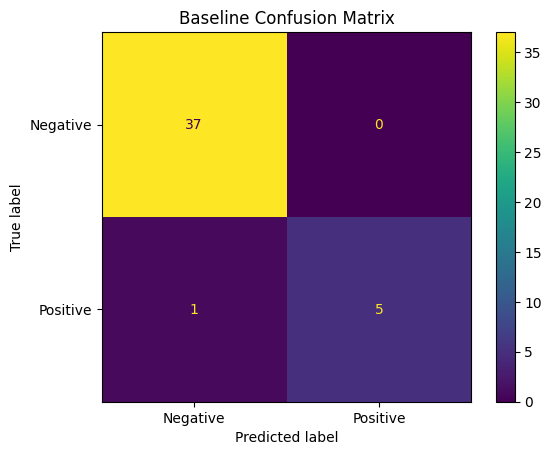

In [68]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_prediction,
    display_labels=[
        "Negative",
        "Positive"
    ],
    values_format="d"
)

plt.title("Baseline Confusion Matrix")
plt.show()

In [73]:
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [74]:
# Store the results, fitted models, and predictions
results_list = []
fitted_models = {}
test_predictions = {}
test_probabilities = {}


def show_class_counts(y_values, title):
    """
    Display class counts and percentages.
    """

    counts = (
        pd.Series(y_values)
        .value_counts()
        .sort_index()
        .rename_axis("Class")
        .to_frame("Count")
    )

    counts["Label"] = counts.index.map(
        {
            0: "Negative",
            1: "Positive"
        }
    )

    counts["Percentage"] = (
        counts["Count"] / counts["Count"].sum() * 100
    )

    print(title)
    display(counts.round(2))


def evaluate_model(method_name, model):
    """
    Fit a model on the training set and evaluate it on the
    original untouched test set.
    """

    # Fit the complete pipeline
    model.fit(X_train, y_train)

    # Class predictions and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion-matrix values
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    result = {
        "Method": method_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1-score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    # Replace an existing result if the cell is rerun
    global results_list

    results_list = [
        row for row in results_list
        if row["Method"] != method_name
    ]

    results_list.append(result)

    fitted_models[method_name] = model
    test_predictions[method_name] = y_pred
    test_probabilities[method_name] = y_prob

    print("=" * 60)
    print(method_name)
    print("=" * 60)

    display(
        pd.DataFrame([result])[
            [
                "Accuracy",
                "Balanced Accuracy",
                "Precision",
                "Recall",
                "Specificity",
                "F1-score",
                "ROC-AUC",
                "TN",
                "FP",
                "FN",
                "TP"
            ]
        ].round(4)
    )

    return result

In [75]:
evaluate_model(
    method_name="Baseline",
    model=baseline_model
)

Baseline


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.9767,0.9167,1.0,0.8333,1.0,0.9091,0.973,37,0,1,5


{'Method': 'Baseline',
 'Accuracy': 0.9767441860465116,
 'Balanced Accuracy': np.float64(0.9166666666666667),
 'Precision': 1.0,
 'Recall': 0.8333333333333334,
 'Specificity': np.float64(1.0),
 'F1-score': 0.9090909090909091,
 'ROC-AUC': np.float64(0.972972972972973),
 'TN': np.int64(37),
 'FP': np.int64(0),
 'FN': np.int64(1),
 'TP': np.int64(5)}

## Part A: Random Undersampling

Random undersampling removes samples from the majority class.

We will compare:

Majority-to-minority ratio of 3:1
Majority-to-minority ratio of 2:1
Completely balanced ratio of 1:1

In [77]:
undersampling_strategies = {
    "Undersampling 3:1": 1 / 3,
    "Undersampling 2:1": 0.5,
    "Undersampling 1:1": 1.0
}

for method_name, ratio in undersampling_strategies.items():

    # Create a temporary sampler only to inspect class counts
    count_sampler = RandomUnderSampler(
        sampling_strategy=ratio,
        random_state=RANDOM_STATE
    )

    X_under_demo, y_under_demo = (
        count_sampler.fit_resample(
            X_train,
            y_train
        )
    )

    show_class_counts(
        y_under_demo,
        title=f"Training distribution after {method_name}"
    )

    # Actual trainable pipeline
    undersampling_model = ImbPipeline(
        steps=[
            (
                "undersampler",
                RandomUnderSampler(
                    sampling_strategy=ratio,
                    random_state=RANDOM_STATE
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight=None,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    evaluate_model(
        method_name=method_name,
        model=undersampling_model
    )

Training distribution after Undersampling 3:1


,Count,Label,Percentage
Class,,,
0,69,Negative,75.0
1,23,Positive,25.0


Undersampling 3:1


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.9535,0.9032,0.8333,0.8333,0.973,0.8333,0.9144,36,1,1,5


Training distribution after Undersampling 2:1


...

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9099,35,2,1,5


Training distribution after Undersampling 1:1


,Count,Label,Percentage
Class,,,
0,23,Negative,50.0
1,23,Positive,50.0


Undersampling 1:1


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.907,0.8761,0.625,0.8333,0.9189,0.7143,0.9189,34,3,1,5


In [78]:
part_a_methods = [
    "Baseline",
    "Undersampling 3:1",
    "Undersampling 2:1",
    "Undersampling 1:1"
]

part_a_results = pd.DataFrame(
    [
        row for row in results_list
        if row["Method"] in part_a_methods
    ]
)

part_a_results["Order"] = (
    part_a_results["Method"]
    .map({
        name: index
        for index, name in enumerate(part_a_methods)
    })
)

part_a_results = (
    part_a_results
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(
    part_a_results[
        [
            "Method",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "FP",
            "FN"
        ]
    ].round(4)
)

,Method,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,FP,FN
0,Baseline,0.9767,0.9167,1.0000,0.8333,1.0000,0.9091,0.9730,0,1
1,Undersampling 3:1,0.9535,0.9032,0.8333,0.8333,0.9730,0.8333,0.9144,1,1
2,Undersampling 2:1,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9099,2,1
3,Undersampling 1:1,0.9070,0.8761,0.6250,0.8333,0.9189,0.7143,0.9189,3,1


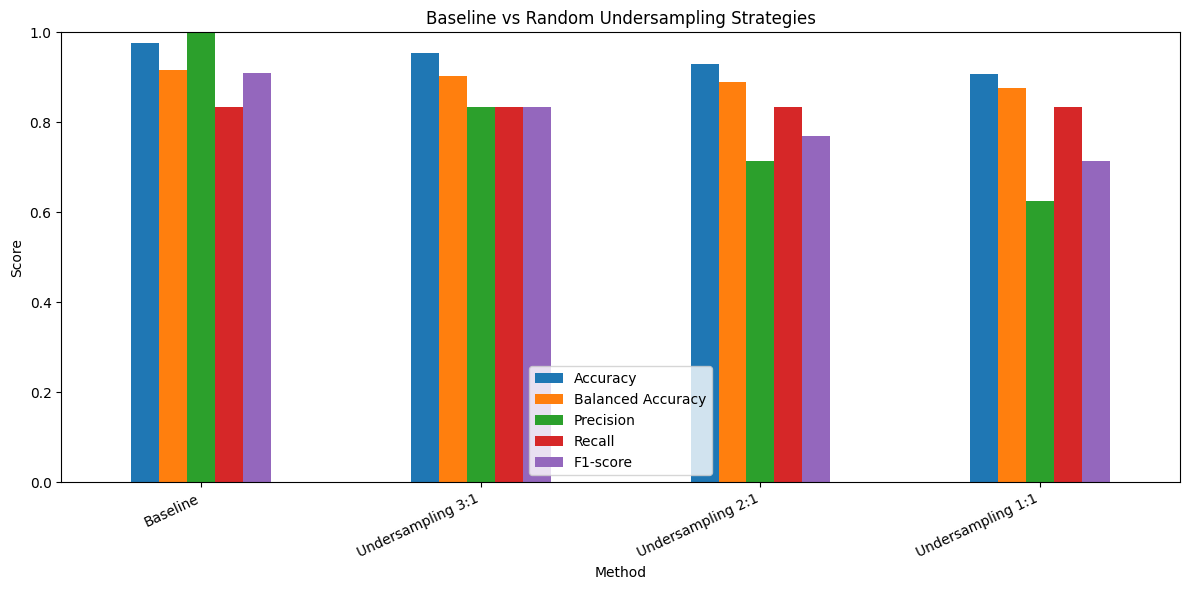

In [79]:
part_a_plot = (
    part_a_results
    .set_index("Method")[
        [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ]
    ]
)

part_a_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Baseline vs Random Undersampling Strategies"
)
plt.xlabel("Method")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Analysis of Random Undersampling Results

The baseline model achieved the strongest performance among the evaluated
models. It correctly classified all 37 negative test samples and five of the
six positive samples, producing only one false negative and no false
positives.

All three undersampling strategies achieved the same positive-class recall of
0.8333. Therefore, undersampling did not help the classifier detect any
additional positive samples. Instead, increasingly aggressive undersampling
caused more negative samples to be classified incorrectly as positive.

The 3:1 undersampling strategy produced one false positive, the 2:1 strategy
produced two false positives, and the balanced 1:1 strategy produced three
false positives. Consequently, precision, specificity, accuracy, and F1-score
decreased as more majority-class samples were removed.

The baseline achieved the highest balanced accuracy of 0.9167, the highest
F1-score of 0.9091, and the highest ROC-AUC of 0.9730. These results indicate
that the original training data already allowed Logistic Regression to
separate the two classes effectively. Random undersampling discarded useful
negative-class information without improving positive-class recall.

Therefore, for this train-test split, random undersampling did not improve
model performance, and the baseline model remained preferable.

## Part B: Random Oversampling 

In [80]:
oversampling_strategies = {
    "Oversampling 2:1": 0.5,
    "Oversampling 1:1": 1.0
}

for method_name, ratio in oversampling_strategies.items():

    # Temporary sampler used only to display new class counts
    count_sampler = RandomOverSampler(
        sampling_strategy=ratio,
        random_state=RANDOM_STATE
    )

    X_over_demo, y_over_demo = (
        count_sampler.fit_resample(
            X_train,
            y_train
        )
    )

    show_class_counts(
        y_over_demo,
        title=f"Training distribution after {method_name}"
    )

    oversampling_model = ImbPipeline(
        steps=[
            (
                "oversampler",
                RandomOverSampler(
                    sampling_strategy=ratio,
                    random_state=RANDOM_STATE
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight=None,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    evaluate_model(
        method_name=method_name,
        model=oversampling_model
    )

Training distribution after Oversampling 2:1


,Count,Label,Percentage
Class,,,
0,147,Negative,66.82
1,73,Positive,33.18


Oversampling 2:1


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9775,35,2,1,5


Training distribution after Oversampling 1:1


,Count,Label,Percentage
Class,,,
0,147,Negative,50.0
1,147,Positive,50.0


Oversampling 1:1


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.907,0.8761,0.625,0.8333,0.9189,0.7143,0.973,34,3,1,5


In [81]:
part_b_methods = [
    "Baseline",
    "Undersampling 3:1",
    "Undersampling 2:1",
    "Undersampling 1:1",
    "Oversampling 2:1",
    "Oversampling 1:1"
]

part_b_results = pd.DataFrame(
    [
        row for row in results_list
        if row["Method"] in part_b_methods
    ]
)

part_b_results["Order"] = (
    part_b_results["Method"]
    .map({
        name: index
        for index, name in enumerate(part_b_methods)
    })
)

part_b_results = (
    part_b_results
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(
    part_b_results[
        [
            "Method",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "FP",
            "FN"
        ]
    ].round(4)
)

,Method,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,FP,FN
0,Baseline,0.9767,0.9167,1.0000,0.8333,1.0000,0.9091,0.9730,0,1
1,Undersampling 3:1,0.9535,0.9032,0.8333,0.8333,0.9730,0.8333,0.9144,1,1
2,Undersampling 2:1,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9099,2,1
3,Undersampling 1:1,0.9070,0.8761,0.6250,0.8333,0.9189,0.7143,0.9189,3,1
4,Oversampling 2:1,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9775,2,1
5,Oversampling 1:1,0.9070,0.8761,0.6250,0.8333,0.9189,0.7143,0.9730,3,1


## Analysis of Random Oversampling Results

Random oversampling was evaluated using majority-to-minority ratios of 2:1
and 1:1. Both strategies retained all majority-class observations and
increased the number of minority-class records by duplicating existing
positive samples.

The baseline model remained the strongest model at the default classification
threshold of 0.5. It achieved an accuracy of 0.9767, a balanced accuracy of
0.9167, and an F1-score of 0.9091. It correctly detected five of the six
positive test samples and produced no false positives.

Both oversampling strategies obtained the same positive-class recall of
0.8333 as the baseline. Therefore, oversampling did not allow the model to
detect the remaining positive sample. Instead, the 2:1 oversampling strategy
produced two false positives, while the balanced 1:1 strategy produced three
false positives. Consequently, their precision, specificity, accuracy, and
F1-score were lower than those of the baseline.

The 2:1 oversampling and 2:1 undersampling models produced identical class
predictions, as did the two 1:1 models. However, their ROC-AUC scores were
different because ROC-AUC uses continuous probability estimates rather than
only the final class predictions.

The 2:1 oversampling strategy achieved the highest ROC-AUC of 0.9775. This
indicates that it ranked positive observations above negative observations
very effectively across different classification thresholds, even though its
performance at the default threshold was weaker than the baseline.

Overall, random oversampling did not improve minority-class recall for this
test split. Nevertheless, it preserved majority-class data and produced
better ROC-AUC results than random undersampling. At the default threshold,
the baseline remained preferable, while the 2:1 oversampling model may be
worth examining with alternative probability thresholds.

## Part C: SMOTE

In [82]:
# Scale the training data for this demonstration
smote_demo_scaler = StandardScaler()

X_train_scaled_demo = (
    smote_demo_scaler.fit_transform(X_train)
)

smote_demo = SMOTE(
    sampling_strategy=1.0,
    k_neighbors=5,
    random_state=RANDOM_STATE
)

X_smote_demo, y_smote_demo = (
    smote_demo.fit_resample(
        X_train_scaled_demo,
        y_train
    )
)

show_class_counts(
    y_train,
    title="Training distribution before SMOTE"
)

show_class_counts(
    y_smote_demo,
    title="Training distribution after SMOTE"
)

positive_before = int(
    (y_train == 1).sum()
)

positive_after = int(
    (pd.Series(y_smote_demo) == 1).sum()
)

print(
    "Synthetic positive samples generated:",
    positive_after - positive_before
)

Training distribution before SMOTE


,Count,Label,Percentage
Class,,,
0,147,Negative,86.47
1,23,Positive,13.53


Training distribution after SMOTE


,Count,Label,Percentage
Class,,,
0,147,Negative,50.0
1,147,Positive,50.0


Synthetic positive samples generated: 124


In [83]:
smote_model = ImbPipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "smote",
            SMOTE(
                sampling_strategy=1.0,
                k_neighbors=5,
                random_state=RANDOM_STATE
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight=None,
                random_state=RANDOM_STATE
            )
        )
    ]
)

evaluate_model(
    method_name="SMOTE 1:1",
    model=smote_model
)

SMOTE 1:1


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.907,0.8761,0.625,0.8333,0.9189,0.7143,0.9775,34,3,1,5


{'Method': 'SMOTE 1:1',
 'Accuracy': 0.9069767441860465,
 'Balanced Accuracy': np.float64(0.8761261261261262),
 'Precision': 0.625,
 'Recall': 0.8333333333333334,
 'Specificity': np.float64(0.918918918918919),
 'F1-score': 0.7142857142857143,
 'ROC-AUC': np.float64(0.9774774774774775),
 'TN': np.int64(34),
 'FP': np.int64(3),
 'FN': np.int64(1),
 'TP': np.int64(5)}

In [84]:
part_c_methods = [
    "Baseline",
    "Oversampling 2:1",
    "Oversampling 1:1",
    "SMOTE 1:1"
]

part_c_results = pd.DataFrame(
    [
        row for row in results_list
        if row["Method"] in part_c_methods
    ]
)

part_c_results["Order"] = (
    part_c_results["Method"]
    .map({
        name: index
        for index, name in enumerate(part_c_methods)
    })
)

part_c_results = (
    part_c_results
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(
    part_c_results[
        [
            "Method",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "FP",
            "FN"
        ]
    ].round(4)
)

,Method,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,FP,FN
0,Baseline,0.9767,0.9167,1.0000,0.8333,1.0000,0.9091,0.9730,0,1
1,Oversampling 2:1,0.9302,0.8896,0.7143,0.8333,0.9459,0.7692,0.9775,2,1
2,Oversampling 1:1,0.9070,0.8761,0.6250,0.8333,0.9189,0.7143,0.9730,3,1
3,SMOTE 1:1,0.9070,0.8761,0.6250,0.8333,0.9189,0.7143,0.9775,3,1


## C. SMOTE

SMOTE stands for **Synthetic Minority Over-sampling Technique**. Random
oversampling balances the training data by duplicating existing minority
records, whereas SMOTE creates new synthetic records.

For an existing minority sample $x_i$, SMOTE selects one of its nearest
minority-class neighbors $x_j$. It then generates a synthetic sample at a
random point between them:

$$
x_{\mathrm{new}} = x_i + \lambda \left(x_j - x_i\right),
\qquad 0 \leq \lambda \leq 1
$$

where:

- $x_i$ is an existing minority-class sample.
- $x_j$ is one of its nearest minority-class neighbors.
- $\lambda$ is a randomly selected value between 0 and 1.
- $x_{\mathrm{new}}$ is the generated synthetic sample.

The features were standardized before applying SMOTE because the algorithm
uses nearest-neighbor distances. Without standardization, variables with
larger numerical ranges could dominate the distance calculation.

SMOTE and random oversampling both created balanced training sets, but SMOTE
generated interpolated records instead of exact duplicates. Their performance
was compared using the same untouched test set.

## Comparison of Oversampling and SMOTE Results

The baseline model achieved the best performance at the default classification
threshold. It obtained the highest accuracy, balanced accuracy, precision, and
F1-score, while producing no false positives and only one false negative.

Random oversampling and SMOTE did not improve positive-class recall, since all
methods achieved the same recall of 0.8333. Instead, the balanced 1:1 methods
increased the number of false positives and reduced precision.

SMOTE 1:1 produced the same final class predictions as random oversampling
1:1. However, its ROC-AUC of 0.9775 was slightly higher, indicating better
probability ranking across different thresholds.

Overall, the baseline remained the best model at the default threshold, while
SMOTE and oversampling mainly increased sensitivity to the positive class at
the cost of more false-positive predictions.

## Part D: Cost-Sensitive Learning

In [85]:
classes = np.sort(
    y_train.unique()
)

calculated_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight
    in zip(classes, calculated_weights)
}

print("Calculated class weights:")
print(class_weight_dict)

Calculated class weights:
{0: 0.5782312925170068, 1: 3.6956521739130435}


In [86]:
training_class_counts = (
    y_train
    .value_counts()
    .sort_index()
)

weight_table = pd.DataFrame(
    {
        "Class": classes,
        "Label": [
            "Negative",
            "Positive"
        ],
        "Training Count": [
            training_class_counts.loc[class_id]
            for class_id in classes
        ],
        "Calculated Weight": [
            class_weight_dict[int(class_id)]
            for class_id in classes
        ]
    }
)

display(
    weight_table.round(4)
)

,Class,Label,Training Count,Calculated Weight
0,0,Negative,147,0.5782
1,1,Positive,23,3.6957


As we can see from above, class 1 receives a considerably larger weight because it is the minority class.

In [87]:
cost_sensitive_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight=class_weight_dict,
                random_state=RANDOM_STATE
            )
        )
    ]
)

evaluate_model(
    method_name="Cost-sensitive",
    model=cost_sensitive_model
)

Cost-sensitive


,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.907,0.8761,0.625,0.8333,0.9189,0.7143,0.9685,34,3,1,5


{'Method': 'Cost-sensitive',
 'Accuracy': 0.9069767441860465,
 'Balanced Accuracy': np.float64(0.8761261261261262),
 'Precision': 0.625,
 'Recall': 0.8333333333333334,
 'Specificity': np.float64(0.918918918918919),
 'F1-score': 0.7142857142857143,
 'ROC-AUC': np.float64(0.9684684684684685),
 'TN': np.int64(34),
 'FP': np.int64(3),
 'FN': np.int64(1),
 'TP': np.int64(5)}

In [88]:
print(
    classification_report(
        y_test,
        test_predictions["Cost-sensitive"],
        labels=[0, 1],
        target_names=[
            "Negative",
            "Positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.97      0.92      0.94        37
    Positive       0.62      0.83      0.71         6

    accuracy                           0.91        43
   macro avg       0.80      0.88      0.83        43
weighted avg       0.92      0.91      0.91        43



In [89]:
part_d_methods = [
    "Baseline",
    "Undersampling 1:1",
    "Oversampling 1:1",
    "SMOTE 1:1",
    "Cost-sensitive"
]

part_d_results = pd.DataFrame(
    [
        row for row in results_list
        if row["Method"] in part_d_methods
    ]
)

part_d_results["Order"] = (
    part_d_results["Method"]
    .map({
        name: index
        for index, name in enumerate(part_d_methods)
    })
)

part_d_results = (
    part_d_results
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(
    part_d_results[
        [
            "Method",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "FP",
            "FN"
        ]
    ].round(4)
)

,Method,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,FP,FN
0,Baseline,0.9767,0.9167,1.000,0.8333,1.0000,0.9091,0.9730,0,1
1,Undersampling 1:1,0.9070,0.8761,0.625,0.8333,0.9189,0.7143,0.9189,3,1
2,Oversampling 1:1,0.9070,0.8761,0.625,0.8333,0.9189,0.7143,0.9730,3,1
3,SMOTE 1:1,0.9070,0.8761,0.625,0.8333,0.9189,0.7143,0.9775,3,1
4,Cost-sensitive,0.9070,0.8761,0.625,0.8333,0.9189,0.7143,0.9685,3,1


## Final Comparison of Imbalance-Handling Methods

The baseline model achieved the best performance at the default threshold of
0.5. It obtained the highest accuracy, balanced accuracy, precision, and
F1-score, with no false positives and only one false negative.

Undersampling, oversampling, SMOTE, and cost-sensitive learning all produced
the same final class predictions. They maintained the same recall of 0.8333 as
the baseline but increased the number of false positives from 0 to 3.
Consequently, their precision decreased to 0.625 and their F1-score decreased
to 0.7143.

Although SMOTE had the highest ROC-AUC of 0.9775, it did not outperform the
baseline at the default classification threshold. Overall, the baseline was
the preferred model for this test split.